# 00 -- Foundation

Ground-up rebuild, self-contained. Loads directly from `data/` -- no code imported from
`deprecated/`. The two call-option tables are read from the pre-parsed parquet cache
already sitting in `data/processed/` (that's a *data* artifact, not code -- reading it is
no different from reading any other file in `data/`); the two spot-price tables are
parsed fresh from their raw Excel files below, written directly against the actual sheet
layout (verified by inspection, not assumed).

This notebook only loads data and defines the (parameterized, no-fixed-window)
volatility/beta machinery that every later notebook re-implements for itself. It does not
pick a window, a leverage constant, a moneyness bucket, or anything else -- those are
determined empirically in the lever notebooks that follow.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]  # scripts/sandbox/ -> project root
DATA = ROOT / "data"
%matplotlib inline

## Load TSLA spot -- fresh parse of `Excel3_Underlying_Data.xlsx`, sheet "TSLA"

Verified by direct inspection: the data starts at Excel header row 11 (0-indexed row 10),
columns are Date/Open/High/Low/Close/Total Return Idx/Volume/Mkt Cap ($M).

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index()
tsla_spot = tsla_spot.dropna()

print(f"TSLA spot: {len(tsla_spot):,} rows, {tsla_spot.index.min().date()} -> {tsla_spot.index.max().date()}")
tsla_spot.head(3)

TSLA spot: 1,571 rows, 2020-06-01 -> 2026-06-08


Date
2020-06-01    59.8733
2020-06-02    58.7707
2020-06-03    58.8640
Name: Close, dtype: float64

## Load TSLL spot -- fresh parse of `TSLL_ohlcv.xlsx`

Single clean sheet, no header offset needed. Columns: Date/Adj Close/Close/High/Low/Open/Volume.

In [3]:
tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index()
tsll_spot = tsll_spot.dropna()

print(f"TSLL spot: {len(tsll_spot):,} rows, {tsll_spot.index.min().date()} -> {tsll_spot.index.max().date()}")
tsll_spot.head(3)

TSLL spot: 963 rows, 2022-08-09 -> 2026-06-10


Date
2022-08-09    24.129999
2022-08-10    25.450001
2022-08-11    24.520000
Name: Close, dtype: float64

## Load call-option chains -- pre-parsed data artifacts (not code) from `data/processed/`

These parquet files are already-parsed, already-validated data tables sitting inside
`data/` -- reading them with `pd.read_parquet` is reading data, not importing any parsing
logic. Columns: raw_id, figi, expiry, strike, date, px_last, px_volume.

In [4]:
tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

for name, df in [("TSLA calls", tsla_calls), ("TSLL calls", tsll_calls)]:
    print(f"{name}: {len(df):,} rows, {df['raw_id'].nunique():,} contracts, "
          f"dates {df['date'].min().date()} -> {df['date'].max().date()}")

tsla_calls.head(3)

TSLA calls: 532,258 rows, 3,786 contracts, dates 2020-01-02 -> 2026-06-10
TSLL calls: 46,867 rows, 689 contracts, dates 2022-08-12 -> 2026-06-10


,raw_id,figi,expiry,strike,date,px_last,px_volume
0,BBG00J7GWRB8 Equity,BBG00J7GWRB8,2020-01-17,50.0,2020-01-03,399.7,6.0
1,BBG00J7GWRB8 Equity,BBG00J7GWRB8,2020-01-17,50.0,2020-01-06,392.9,1.0
2,BBG00J7GWRB8 Equity,BBG00J7GWRB8,2020-01-17,50.0,2020-01-07,407.1,6.0


## Daily returns

In [5]:
r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()

# common trading-date index, bounded by TSLL (the sparser series -- inception 2022-08-09)
common_dates = r_tsla.index.intersection(r_tsll.index)
r_tsla = r_tsla.loc[common_dates]
r_tsll = r_tsll.loc[common_dates]

print(f"Common return series: {len(common_dates):,} days, {common_dates.min().date()} -> {common_dates.max().date()}")

Common return series: 960 days, 2022-08-10 -> 2026-06-08


## Parameterized estimation machinery -- window is an ARGUMENT, nothing fixed here

`VOL_WINDOW` used to be a hardcoded constant (21) everywhere in the old codebase.
`TSLL_LEVER` used to be a hardcoded constant (2.0) everywhere. Neither is assumed here --
both functions below take the lookback window as an explicit argument, and
`lever0_estimation_window_sandbox.ipynb` is the notebook that empirically determines what
that window should be before anything downstream uses it. `rolling_beta` replaces the
fixed 2.0x leverage assumption with a genuine trailing-window regression, lagged 1 day so
it never uses same-day information.

In [6]:
def rolling_vol(returns: pd.Series, window: int) -> pd.Series:
    """Annualized realized volatility, trailing `window` days. Not lagged here -- callers
    that use this as a same-day Black-Scholes input are, by construction, using only
    information through and including that day's own past window (the return on day t
    itself is not known until day t closes, so this is already point-in-time honest for
    a decision made at day t's close)."""
    return returns.rolling(window).std() * np.sqrt(252)


def rolling_beta(dependent: pd.Series, independent: pd.Series, window: int) -> pd.Series:
    """Trailing-window OLS slope of `dependent` (e.g. TSLL returns) on `independent`
    (e.g. TSLA returns), lagged 1 day -- the beta used to size a hedge on day t is
    computed only from returns strictly before day t, never including it."""
    cov = dependent.rolling(window).cov(independent)
    var = independent.rolling(window).var()
    beta = (cov / var).shift(1)
    return beta


# quick sanity demo at one arbitrary window (NOT a chosen default -- just proving the
# functions work end to end before Lever 0 decides what window to actually use)
_demo_window = 21
_demo_sigma = rolling_vol(r_tsll, _demo_window)
_demo_beta = rolling_beta(r_tsll, r_tsla, _demo_window)
print(f"Demo (window={_demo_window}): sigma range {_demo_sigma.min():.3f}-{_demo_sigma.max():.3f}, "
      f"beta range {_demo_beta.min():.3f}-{_demo_beta.max():.3f}")
print("(This window is illustrative only -- Lever 0 determines the real one.)")

Demo (window=21): sigma range 0.404-2.341, beta range 1.454-2.021
(This window is illustrative only -- Lever 0 determines the real one.)


## Sanity checks

In [7]:
assert tsla_spot.isna().sum() == 0, "TSLA spot has NaNs"
assert tsll_spot.isna().sum() == 0, "TSLL spot has NaNs"
assert r_tsla.isna().sum() == 0, "TSLA returns have NaNs"
assert r_tsll.isna().sum() == 0, "TSLL returns have NaNs"
assert len(tsla_calls) > 0 and len(tsll_calls) > 0, "call chains empty"
assert (tsla_calls["px_last"] > 0).all() or tsla_calls["px_last"].isna().any(), "non-positive TSLA call prices present"

print("All foundation sanity checks passed.")

All foundation sanity checks passed.


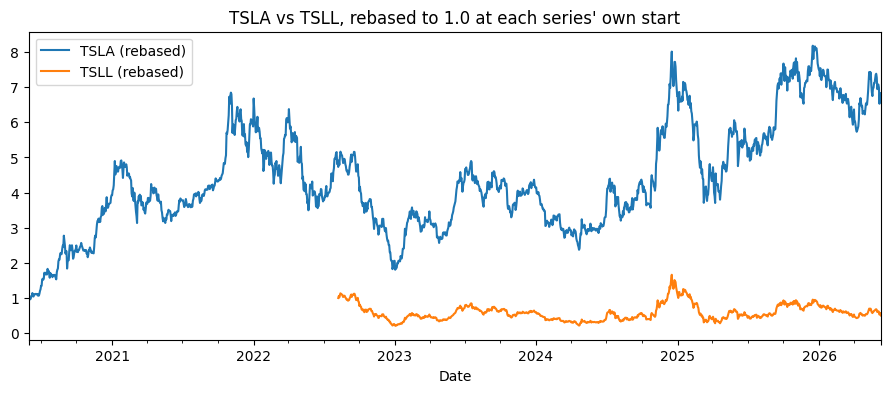

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
(tsla_spot / tsla_spot.iloc[0]).plot(ax=ax, label="TSLA (rebased)")
(tsll_spot / tsll_spot.iloc[0]).plot(ax=ax, label="TSLL (rebased)")
ax.set_title("TSLA vs TSLL, rebased to 1.0 at each series' own start")
ax.legend()
plt.show()